# Kelvin examples migration ledger

`examples/kelvin_transformation/` contains several different kinds of Python files: classic explanatory demos, validation-locked samples, DtN/open-boundary research prototypes, and adaptive-mesh scratch/convergence studies. This notebook records the migration ledger before deleting or moving anything.

Policy: result-bearing docs notebooks are the human-facing layer; validation-class scripts belong in `validation_test/` or stay as protected validation corpus until an executable replacement exists.

In [1]:
from pathlib import Path
import sys

NOTEBOOK_DIR = Path.cwd()
if not (NOTEBOOK_DIR / 'kelvin_examples_migration.py').exists():
    NOTEBOOK_DIR = Path('docs/kelvin').resolve()
sys.path.insert(0, str(NOTEBOOK_DIR))

from kelvin_examples_migration import build_migration_report, write_report_json, short_summary

report = build_migration_report()
json_path = write_report_json(report, NOTEBOOK_DIR / 'kelvin_examples_migration_results.json')
print(short_summary(report))
print(f'\nwrote {json_path.relative_to(NOTEBOOK_DIR)}')

python files: 144
tracked python files: 144
validation-named python files: 7
referenced python files (reported): 17
migration lanes: open_boundary_src_api_or_validation=104, validation_test_or_src_api_locked=17, collapse_to_notebook_or_memory=14, validation_test_candidate=7, validation_test_locked_sample=2
top groups: DtN_spectrum=122, AdaptiveMesh=14, A-formulation=3, Omega_ReducedOmega=3, Cubit_1_4_p_convergence=2

wrote kelvin_examples_migration_results.json


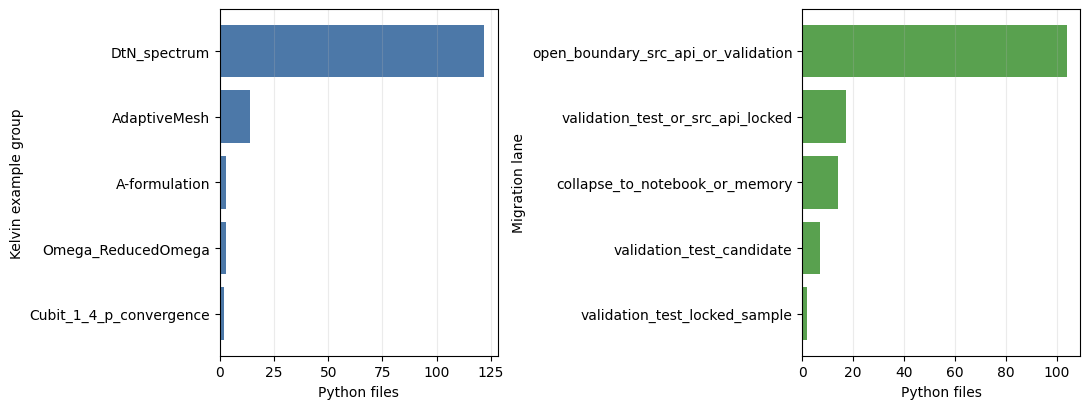

In [2]:
import matplotlib.pyplot as plt

summary = report['summary']
fig, axes = plt.subplots(1, 2, figsize=(11.0, 4.2))

groups = summary['top_groups']
axes[0].barh(list(groups.keys())[::-1], list(groups.values())[::-1], color='#4c78a8')
axes[0].set_xlabel('Python files')
axes[0].set_ylabel('Kelvin example group')
axes[0].grid(axis='x', alpha=0.25)

lanes = summary['migration_lanes']
axes[1].barh(list(lanes.keys())[::-1], list(lanes.values())[::-1], color='#59a14f')
axes[1].set_xlabel('Python files')
axes[1].set_ylabel('Migration lane')
axes[1].grid(axis='x', alpha=0.25)

fig.tight_layout()
plt.show()

In [3]:
from IPython.display import Markdown, display
from kelvin_examples_migration import markdown_table

display(Markdown('## Recommended batches'))
display(Markdown(markdown_table(report['recommended_batches'], ['name', 'lane', 'description'], max_rows=10)))

display(Markdown('## Referenced or validation-named examples'))
review_rows = [
    {
        'path': row['path'],
        'lane': row['migration_lane'],
        'validation_named': row['validation_named'],
        'refs': row['reference_hit_count_reported'],
        'artifacts': ', '.join(row['sibling_artifacts'][:3]),
    }
    for row in report['files']
    if row['validation_named'] or row['reference_hit_count_reported']
]
display(Markdown(markdown_table(review_rows, ['path', 'lane', 'validation_named', 'refs', 'artifacts'], max_rows=30)))

## Recommended batches

| name | lane | description |
| --- | --- | --- |
| classic_kelvin_demo_notebook | docs_classic_demo_candidate | A/H/Omega formulation demos rendered as one or two docs notebooks. |
| cubit_p_convergence | validation_test_locked_sample | Keep as validation-backed sample; docs may point at the result but should not replace it. |
| dtn_spectrum | open_boundary_src_api_or_validation | Port stable act scripts into radia.open_boundary/src APIs or validation_test before pruning prototypes. |
| adaptive_mesh | collapse_to_notebook_or_memory | Summarize convergence families into docs notebook/JSON, then prune superseded per-order scripts only after distilling lessons. |

## Referenced or validation-named examples

| path | lane | validation_named | refs | artifacts |
| --- | --- | --- | --- | --- |
| examples/kelvin_transformation/A-formulation/validate_B_pullback_energy.py | validation_test_candidate | True | 0 |  |
| examples/kelvin_transformation/A-formulation/validate_radia_HB_kelvin.py | validation_test_candidate | True | 0 |  |
| examples/kelvin_transformation/A-formulation/validate_radia_vs_fem_kelvin.py | validation_test_candidate | True | 0 |  |
| examples/kelvin_transformation/DtN_spectrum/act0_02_p_vs_h_study.py | validation_test_or_src_api_locked | False | 1 |  |
| examples/kelvin_transformation/DtN_spectrum/act1_07_inductance_dtn.py | validation_test_or_src_api_locked | False | 1 |  |
| examples/kelvin_transformation/DtN_spectrum/act2_03_floor_vs_curve.py | validation_test_or_src_api_locked | False | 2 |  |
| examples/kelvin_transformation/DtN_spectrum/act2_04_adequacy_eccentric_multibody.py | validation_test_or_src_api_locked | False | 1 |  |
| examples/kelvin_transformation/DtN_spectrum/act2_05_geometry_floor_law.py | validation_test_or_src_api_locked | False | 1 |  |
| examples/kelvin_transformation/DtN_spectrum/act2_09_exterior_mesh.py | validation_test_or_src_api_locked | False | 1 |  |
| examples/kelvin_transformation/DtN_spectrum/act2_15_nonsymmetric_validation.py | validation_test_candidate | True | 0 |  |
| examples/kelvin_transformation/DtN_spectrum/act6_01_kelvin_fem_eddy_dtn.py | validation_test_or_src_api_locked | False | 2 |  |
| examples/kelvin_transformation/DtN_spectrum/act6_02_cln_dtn_cauer.py | validation_test_or_src_api_locked | False | 3 |  |
| examples/kelvin_transformation/DtN_spectrum/act6_09_cln_vs_pml.py | validation_test_or_src_api_locked | False | 1 |  |
| examples/kelvin_transformation/DtN_spectrum/act6_11_exact_dtn_fetd.py | validation_test_or_src_api_locked | False | 1 |  |
| examples/kelvin_transformation/DtN_spectrum/act7_21_lowfreq_openbc_4way.py | validation_test_or_src_api_locked | False | 1 |  |
| examples/kelvin_transformation/DtN_spectrum/act7_22_dtn_spectrum_consolidated.py | validation_test_or_src_api_locked | False | 1 | act7_22_dtn_spectrum_consolidated.json, act7_22_dtn_spectrum_consolidated.png, act7_22_dtn_spectrum_consolidated.pdf |
| examples/kelvin_transformation/DtN_spectrum/act7_25_infinite_element_dtn.py | validation_test_or_src_api_locked | False | 1 | act7_25_infinite_element_dtn.json |
| examples/kelvin_transformation/DtN_spectrum/act7_26_derham_infinite_element.py | validation_test_or_src_api_locked | False | 2 | act7_26_derham_infinite_element.json |
| examples/kelvin_transformation/DtN_spectrum/act7_27_ie_vs_kelvin_vs_pml_gate1.py | validation_test_or_src_api_locked | False | 2 | act7_27_ie_vs_kelvin_vs_pml_gate1.json |
| examples/kelvin_transformation/DtN_spectrum/act7_28_ie_vs_kelvin_fair_dtn.py | validation_test_or_src_api_locked | False | 4 | act7_28_ie_vs_kelvin_fair_dtn.json |
| examples/kelvin_transformation/DtN_spectrum/act7_32_ie_3d_assembly_validation.py | validation_test_candidate | True | 0 | act7_32_ie_3d_assembly_validation.json |
| examples/kelvin_transformation/Omega_ReducedOmega/Cylinder/validate_radia_vs_fem_cylinder.py | validation_test_candidate | True | 0 |  |
| examples/kelvin_transformation/Omega_ReducedOmega/test_solver_integration.py | validation_test_or_src_api_locked | False | 1 |  |
| examples/kelvin_transformation/Omega_ReducedOmega/validate_omega_coil_source_v2.py | validation_test_candidate | True | 0 |  |

## Next migration step

Start with `docs_classic_demo_candidate`: the A-formulation, H-formulation, and Omega-ReducedOmega demos are the best fit for a rendered tutorial notebook. Keep `Cubit_1_4_p_convergence` in the validation-backed sample lane. Treat `DtN_spectrum` as an open-boundary source/API migration, not a docs-only cleanup.